In [1]:
import numpy as np
import sympy as sp
from jetgp.full_ddegp.ddegp import ddegp
import jetgp.utils as utils
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 1
n_bases = 2
num_training_pts = 16
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 50

# Global set of directional rays (45°, 90°, 135°)
rays = np.array([
    [np.cos(np.pi/4), np.cos(np.pi/2), np.cos(3*np.pi/4)],
    [np.sin(np.pi/4), np.sin(np.pi/2), np.sin(3*np.pi/4)]
])

normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 1
np.random.seed(random_seed)

print("Configuration complete!")
print(f"Number of training points: {num_training_pts}")
print(f"Number of directional rays: {rays.shape[1]}")
print(f"Ray directions:")
for i in range(rays.shape[1]):
    angle_deg = np.arctan2(rays[1, i], rays[0, i]) * 180 / np.pi
    print(f"  Ray {i+1}: [{rays[0, i]:+.4f}, {rays[1, i]:+.4f}] (angle: {angle_deg:.1f}°)")

Configuration complete!
Number of training points: 16
Number of directional rays: 3
Ray directions:
  Ray 1: [+0.7071, +0.7071] (angle: 45.0°)
  Ray 2: [+0.0000, +1.0000] (angle: 90.0°)
  Ray 3: [-0.7071, +0.7071] (angle: 135.0°)


In [3]:
def branin_function(X, alg=np):
    """2D Branin function - a common benchmark for optimization."""
    x1, x2 = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4.0*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8.0*np.pi)
    return a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1 - t)*alg.cos(x1) + s

# Define symbolic version for derivatives
x1_sym, x2_sym = sp.symbols('x1 x2')
a, b, c, r, s, t = 1.0, 5.1/(4.0*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8.0*sp.pi)
f_sym = a * (x2_sym - b*x1_sym**2 + c*x1_sym - r)**2 + s*(1 - t)*sp.cos(x1_sym) + s

# Compute gradients symbolically
grad_x1 = sp.diff(f_sym, x1_sym)
grad_x2 = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
f_func = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2, 'numpy')

print("Branin function and symbolic derivatives defined!")

Branin function and symbolic derivatives defined!


In [4]:
# Latin Hypercube Sampling for training points
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples, [b[0] for b in domain_bounds], [b[1] for b in domain_bounds])

# Compute function values
y_func = f_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

# Compute coordinate-aligned gradients
grad_x1_vals = grad_x1_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)
grad_x2_vals = grad_x2_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

# Compute directional derivatives using the chain rule
# For each ray: d_ray = grad_x1 * ray[0] + grad_x2 * ray[1]
directional_derivs = []
for i in range(rays.shape[1]):
    ray_direction = rays[:, i]
    dir_deriv = (grad_x1_vals * ray_direction[0] +
                 grad_x2_vals * ray_direction[1])
    directional_derivs.append(dir_deriv)

# Package training data
y_train_list = [y_func] + directional_derivs
der_indices = [[[[1, 1]], [[2, 1]], [[3, 1]]]]

# Build derivative_locations: all rays at all points
derivative_locations = []
for i in range(len(der_indices)):
    for j in range(len(der_indices[i])):
        derivative_locations.append([k for k in range(len(X_train))])

print(f"Training data generated!")
print(f"X_train shape: {X_train.shape}")
print(f"Function values shape: {y_func.shape}")
print(f"Number of directional derivative arrays: {len(directional_derivs)}")
print(f"derivative_locations: {len(derivative_locations)} entries, each with {len(derivative_locations[0])} points")

Training data generated!
X_train shape: (16, 2)
Function values shape: (16, 1)
Number of directional derivative arrays: 3
derivative_locations: 3 entries, each with 16 points


In [5]:
# Initialize the DDEGP model
gp_model = ddegp(
    X_train,
    y_train_list,
    n_order=n_order,
    der_indices=der_indices,
    derivative_locations=derivative_locations,
    rays=rays,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("DDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

DDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [-0.02596297 -0.89539419  1.35052575 -6.9867352 ]


In [6]:
# Create dense test grid
x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {len(X_test)} points")

# Predict on test grid
y_pred_full = gp_model.predict(X_test, params, calc_cov=False, return_deriv=False)
y_pred = y_pred_full[0, :]  # Row 0: function values

# Compute ground truth and error
y_true = branin_function(X_test, alg=np)
nrmse = utils.nrmse(y_true, y_pred)
abs_error = np.abs(y_true - y_pred)

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

Test grid: 50×50 = 2500 points

Model Performance:
  NRMSE: 0.000910
  Max absolute error: 4.106575
  Mean absolute error: 0.064468


In [7]:
# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_func_values = y_train_list[0]  # Function values

# Predict at training points (function values only)
y_pred_train = gp_model.predict(X_train, params, calc_cov=False, return_deriv=False)

print("Function value interpolation errors:")
print("=" * 70)
for i in range(num_training_pts):
    error_abs = abs(y_pred_train[0, i] - y_func_values[i, 0])
    error_rel = error_abs / abs(y_func_values[i, 0]) if y_func_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x1={X_train[i, 0]:.4f}, x2={X_train[i, 1]:.4f}): "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train[0, :] - y_func_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

Function value interpolation errors:
Point 0 (x1=2.9577, x2=2.8589): Abs Error = 6.09e-07, Rel Error = 8.12e-07
Point 1 (x1=-4.1976, x2=12.2356): Abs Error = 2.43e-07, Rel Error = 1.91e-08
Point 2 (x1=8.7702, x2=8.0406): Abs Error = 3.26e-07, Rel Error = 8.32e-09
Point 3 (x1=9.2240, x2=13.6789): Abs Error = 2.93e-08, Rel Error = 2.26e-10
Point 4 (x1=3.8598, x2=5.5992): Abs Error = 6.52e-07, Rel Error = 3.76e-08
Point 5 (x1=-2.8939, x2=10.7455): Abs Error = 7.55e-07, Rel Error = 4.78e-07
Point 6 (x1=5.9409, x2=5.8233): Abs Error = 1.43e-06, Rel Error = 3.45e-08
Point 7 (x1=6.9033, x2=2.3873): Abs Error = 9.35e-07, Rel Error = 4.85e-08
Point 8 (x1=0.4993, x2=0.5596): Abs Error = 1.12e-06, Rel Error = 2.79e-08
Point 9 (x1=2.3093, x2=4.4416): Abs Error = 5.30e-07, Rel Error = 9.51e-08
Point 10 (x1=-1.9535, x2=1.6121): Abs Error = 7.42e-07, Rel Error = 1.06e-08
Point 11 (x1=4.8576, x2=6.5806): Abs Error = 3.32e-07, Rel Error = 8.50e-09
Point 12 (x1=0.6609, x2=8.6955): Abs Error = 1.87e-06, 

In [8]:
# ------------------------------------------------------------
# Verify directional derivative interpolation
# ------------------------------------------------------------
print("=" * 70)
print("Directional derivative interpolation verification:")
print("=" * 70)
print(f"Number of directional rays: {rays.shape[1]}")
print(f"Ray directions:")
for i in range(rays.shape[1]):
    angle_deg = np.arctan2(rays[1, i], rays[0, i]) * 180 / np.pi
    print(f"  Ray {i+1}: [{rays[0, i]:+.4f}, {rays[1, i]:+.4f}] (angle: {angle_deg:.1f}°)")
print("=" * 70)

# Predict with derivatives - returns [num_derivs + 1, num_points] array
y_pred_with_derivs = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

print(f"\nPrediction with derivatives shape: {y_pred_with_derivs.shape}")
print(f"Expected: [{rays.shape[1] + 1} rows, {num_training_pts} columns]")
print(f"  Row 0: function values")
print(f"  Row 1: Ray 1 derivatives (45°)")
print(f"  Row 2: Ray 2 derivatives (90°)")
print(f"  Row 3: Ray 3 derivatives (135°)")

# Extract predicted values using row indexing
# Row 0: function values, Row 1-3: directional derivatives for each ray
pred_func_vals = y_pred_with_derivs[0, :]
pred_deriv_ray1 = y_pred_with_derivs[1, :]
pred_deriv_ray2 = y_pred_with_derivs[2, :]
pred_deriv_ray3 = y_pred_with_derivs[3, :]

# Extract analytic derivatives from training data
analytic_deriv_ray1 = y_train_list[1]
analytic_deriv_ray2 = y_train_list[2]
analytic_deriv_ray3 = y_train_list[3]

# Verify each ray's directional derivatives
pred_derivs = [pred_deriv_ray1, pred_deriv_ray2, pred_deriv_ray3]
analytic_derivs = [analytic_deriv_ray1, analytic_deriv_ray2, analytic_deriv_ray3]

for ray_idx in range(rays.shape[1]):
    print(f"\n{'-'*70}")
    print(f"Ray {ray_idx + 1} - Direction: [{rays[0, ray_idx]:+.4f}, {rays[1, ray_idx]:+.4f}]")
    print(f"{'-'*70}")

    pred_deriv = pred_derivs[ray_idx]
    analytic_deriv = analytic_derivs[ray_idx].flatten()

    for i in range(num_training_pts):
        error_abs = abs(pred_deriv[i] - analytic_deriv[i])
        error_rel = error_abs / abs(analytic_deriv[i]) if analytic_deriv[i] != 0 else error_abs

        print(f"Point {i} (x1={X_train[i, 0]:.4f}, x2={X_train[i, 1]:.4f}):")
        print(f"  Analytic: {analytic_deriv[i]:+.6f}, Predicted: {pred_deriv[i]:+.6f}")
        print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

    max_deriv_error = np.max(np.abs(pred_deriv.flatten() - analytic_deriv.flatten()))
    print(f"\nMaximum absolute error for Ray {ray_idx + 1}: {max_deriv_error:.2e}")

Directional derivative interpolation verification:
Number of directional rays: 3
Ray directions:
  Ray 1: [+0.7071, +0.7071] (angle: 45.0°)
  Ray 2: [+0.0000, +1.0000] (angle: 90.0°)
  Ray 3: [-0.7071, +0.7071] (angle: 135.0°)
Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]], [[3, 1]]]

Prediction with derivatives shape: (4, 16)
Expected: [4 rows, 16 columns]
  Row 0: function values
  Row 1: Ray 1 derivatives (45°)
  Row 2: Ray 2 derivatives (90°)
  Row 3: Ray 3 derivatives (135°)

----------------------------------------------------------------------
Ray 1 - Direction: [+0.7071, +0.7071]
----------------------------------------------------------------------
Point 0 (x1=2.9577, x2=2.8589):
  Analytic: -0.114669, Predicted: -0.114669
  Abs Error: 2.63e-08, Rel Error: 2.29e-07
Point 1 (x1=-4.1976, x2=12.2356):
  Analytic: -20.057824, Predicted: -20.057824
  Abs Error: 9.80e-08, Rel Error: 4.88e-09
Point 2 (x1=8.7702, x2=8.04

In [9]:
print("=" * 70)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 70)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_training_pts} training points")
print(f"  - Directional derivatives: {rays.shape[1]} rays at each training point")
print(f"  - Total constraints: {num_training_pts} function values + "
      f"{num_training_pts * rays.shape[1]} directional derivatives")
print(f"  - Prediction output shape: [{rays.shape[1] + 1}, {num_training_pts}]")
print(f"  - Row 0: function values")
print(f"  - Row 1: Ray 1 direction [{rays[0, 0]:+.4f}, {rays[1, 0]:+.4f}] "
      f"(angle: {np.arctan2(rays[1, 0], rays[0, 0]) * 180 / np.pi:.1f}°)")
print(f"  - Row 2: Ray 2 direction [{rays[0, 1]:+.4f}, {rays[1, 1]:+.4f}] "
      f"(angle: {np.arctan2(rays[1, 1], rays[0, 1]) * 180 / np.pi:.1f}°)")
print(f"  - Row 3: Ray 3 direction [{rays[0, 2]:+.4f}, {rays[1, 2]:+.4f}] "
      f"(angle: {np.arctan2(rays[1, 2], rays[0, 2]) * 180 / np.pi:.1f}°)")
print("=" * 70)

Interpolation verification complete!
Relative errors should be close to machine precision (< 1e-6)

SUMMARY:
  - Function values: enforced at all 16 training points
  - Directional derivatives: 3 rays at each training point
  - Total constraints: 16 function values + 48 directional derivatives
  - Prediction output shape: [4, 16]
  - Row 0: function values
  - Row 1: Ray 1 direction [+0.7071, +0.7071] (angle: 45.0°)
  - Row 2: Ray 2 direction [+0.0000, +1.0000] (angle: 90.0°)
  - Row 3: Ray 3 direction [-0.7071, +0.7071] (angle: 135.0°)


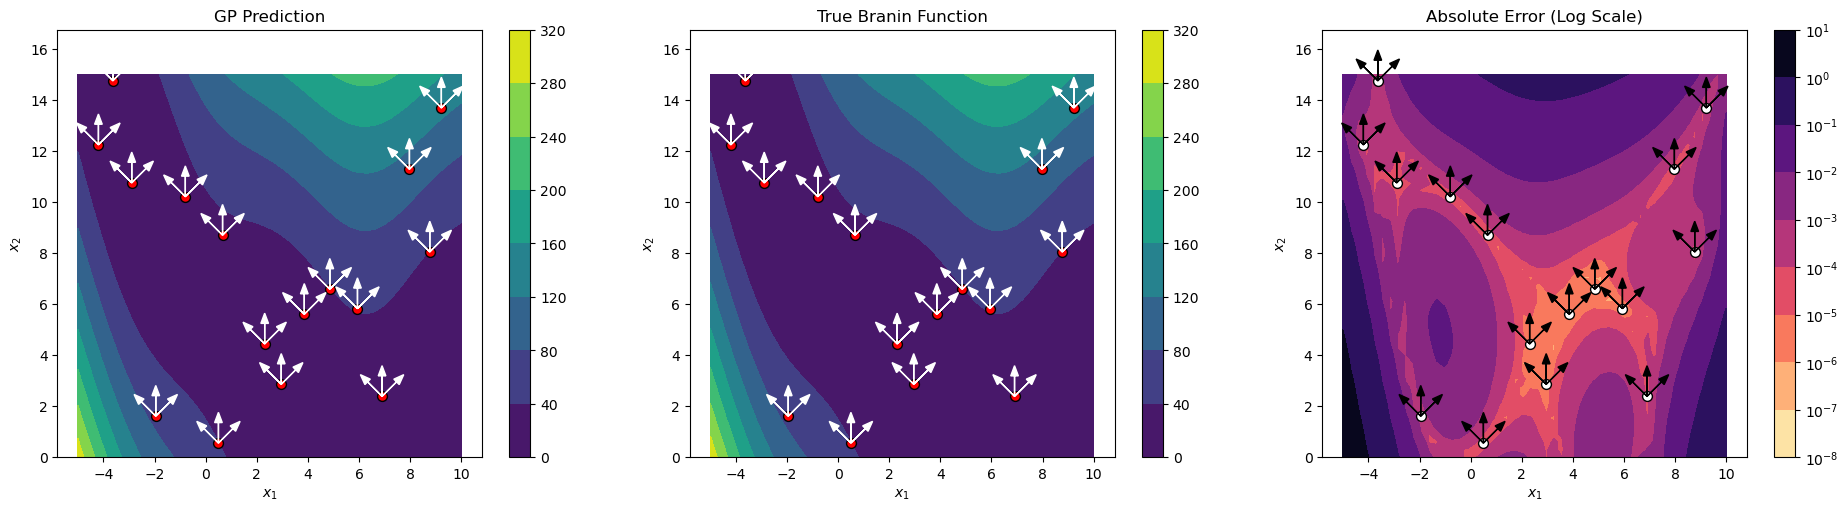


Final NRMSE: 0.000910


In [10]:
# Prepare visualization data
gp_map = y_pred.reshape(X1_grid.shape)
true_map = y_true.reshape(X1_grid.shape)
abs_err = np.abs(gp_map - true_map)
abs_err_clipped = np.clip(abs_err, 1e-8, None)

# Create three-panel figure
fig, axs = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)

# GP Prediction
cf1 = axs[0].contourf(X1_grid, X2_grid, gp_map, cmap='viridis')
fig.colorbar(cf1, ax=axs[0])
axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=50, edgecolors='black')
axs[0].set_title("GP Prediction")

# True Function
cf2 = axs[1].contourf(X1_grid, X2_grid, true_map, cmap='viridis')
fig.colorbar(cf2, ax=axs[1])
axs[1].scatter(X_train[:, 0], X_train[:, 1], c='red', s=50, edgecolors='black')
axs[1].set_title("True Branin Function")

# Absolute Error
cf3 = axs[2].contourf(X1_grid, X2_grid, abs_err_clipped,
                       norm=LogNorm(), cmap='magma_r')
fig.colorbar(cf3, ax=axs[2])
axs[2].scatter(X_train[:, 0], X_train[:, 1], c='white', s=50, edgecolors='black')
axs[2].set_title("Absolute Error (Log Scale)")

# Draw directional rays at each training point
ray_length = 0.8
for ax, color in zip(axs, ['white', 'white', 'black']):
    for pt in X_train:
        for i in range(rays.shape[1]):
            direction = rays[:, i]
            ax.arrow(pt[0], pt[1], direction[0]*ray_length,
                     direction[1]*ray_length, head_width=0.3, head_length=0.4,
                     fc=color, ec=color)

for ax in axs:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")

plt.show()

print(f"\nFinal NRMSE: {nrmse:.6f}")

In [11]:
import numpy as np
import sympy as sp
from jetgp.full_ddegp.ddegp import ddegp
import jetgp.utils as utils
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

In [12]:
n_order = 1
n_bases = 2
num_training_pts = 20
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 50

# Global set of directional rays (45°, 90°, 135°)
rays = np.array([
    [np.cos(np.pi/4), np.cos(np.pi/2), np.cos(3*np.pi/4)],
    [np.sin(np.pi/4), np.sin(np.pi/2), np.sin(3*np.pi/4)]
])

normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 42
np.random.seed(random_seed)

print("=" * 70)
print("DDEGP Tutorial: Selective Derivative Coverage")
print("=" * 70)
print(f"Number of training points: {num_training_pts}")
print(f"Number of directional rays: {rays.shape[1]}")
print(f"Ray directions:")
for i in range(rays.shape[1]):
    angle_deg = np.arctan2(rays[1, i], rays[0, i]) * 180 / np.pi
    print(f"  Ray {i+1}: [{rays[0, i]:+.4f}, {rays[1, i]:+.4f}] (angle: {angle_deg:.1f}°)")

DDEGP Tutorial: Selective Derivative Coverage
Number of training points: 20
Number of directional rays: 3
Ray directions:
  Ray 1: [+0.7071, +0.7071] (angle: 45.0°)
  Ray 2: [+0.0000, +1.0000] (angle: 90.0°)
  Ray 3: [-0.7071, +0.7071] (angle: 135.0°)


In [13]:
def branin_function(X, alg=np):
    """2D Branin function - a common benchmark for optimization."""
    x1, x2 = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4.0*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8.0*np.pi)
    return a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1 - t)*alg.cos(x1) + s

# Define symbolic version for derivatives
x1_sym, x2_sym = sp.symbols('x1 x2')
a, b, c, r, s, t = 1.0, 5.1/(4.0*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8.0*sp.pi)
f_sym = a * (x2_sym - b*x1_sym**2 + c*x1_sym - r)**2 + s*(1 - t)*sp.cos(x1_sym) + s

# Compute gradients symbolically
grad_x1 = sp.diff(f_sym, x1_sym)
grad_x2 = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
f_func = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2, 'numpy')

print("Branin function and symbolic derivatives defined!")

Branin function and symbolic derivatives defined!


In [14]:
# Latin Hypercube Sampling for training points
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples, [b[0] for b in domain_bounds], [b[1] for b in domain_bounds])

# Compute function values at ALL points
y_func = f_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

# Compute coordinate-aligned gradients at ALL points (needed for chain rule)
grad_x1_vals = grad_x1_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)
grad_x2_vals = grad_x2_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

In [15]:
# ==========================================================================
# Define which points have derivatives along each ray
# ==========================================================================
# Divide points based on x1 coordinate
x1_midpoint = (domain_bounds[0][0] + domain_bounds[0][1]) / 2  # = 2.5

left_region_indices = [i for i in range(num_training_pts) if X_train[i, 0] < x1_midpoint]
right_region_indices = [i for i in range(num_training_pts) if X_train[i, 0] >= x1_midpoint]
all_indices = list(range(num_training_pts))

# derivative_locations: one list per ray, containing indices of points with that derivative
derivative_locations = [
    left_region_indices,   # Ray 1 (45°):  only left region
    all_indices,           # Ray 2 (90°):  all points
    right_region_indices   # Ray 3 (135°): only right region
]

print(f"Derivative coverage:")
print(f"  x1 midpoint: {x1_midpoint}")
print(f"  Left region points (x1 < {x1_midpoint}): {len(left_region_indices)} points")
print(f"  Right region points (x1 >= {x1_midpoint}): {len(right_region_indices)} points")
print(f"\nderivative_locations structure:")
print(f"  Ray 1 (45°):  {len(derivative_locations[0])} points - indices {derivative_locations[0]}")
print(f"  Ray 2 (90°):  {len(derivative_locations[1])} points - all points")
print(f"  Ray 3 (135°): {len(derivative_locations[2])} points - indices {derivative_locations[2]}")

Derivative coverage:
  x1 midpoint: 2.5
  Left region points (x1 < 2.5): 10 points
  Right region points (x1 >= 2.5): 10 points

derivative_locations structure:
  Ray 1 (45°):  10 points - indices [1, 2, 4, 6, 7, 8, 13, 14, 15, 18]
  Ray 2 (90°):  20 points - all points
  Ray 3 (135°): 10 points - indices [0, 3, 5, 9, 10, 11, 12, 16, 17, 19]


In [16]:
# ==========================================================================
# Compute directional derivatives ONLY at specified locations
# ==========================================================================
directional_derivs = []
for ray_idx in range(rays.shape[1]):
    ray_direction = rays[:, ray_idx]
    point_indices = derivative_locations[ray_idx]

    # Only compute derivatives at the specified points
    dir_deriv = (grad_x1_vals[point_indices] * ray_direction[0] +
                 grad_x2_vals[point_indices] * ray_direction[1])
    directional_derivs.append(dir_deriv)

    print(f"  Ray {ray_idx + 1}: computed {len(dir_deriv)} directional derivatives")

# Package training data
y_train_list = [y_func] + directional_derivs
der_indices = [[[[1, 1]], [[2, 1]], [[3, 1]]]]

print(f"\nTraining data summary:")
print(f"  X_train shape: {X_train.shape}")
print(f"  Function values: {y_func.shape[0]} (all points)")
print(f"  Ray 1 derivatives: {directional_derivs[0].shape[0]} values")
print(f"  Ray 2 derivatives: {directional_derivs[1].shape[0]} values")
print(f"  Ray 3 derivatives: {directional_derivs[2].shape[0]} values")
print(f"  Total derivative constraints: {sum(len(d) for d in directional_derivs)}")

  Ray 1: computed 10 directional derivatives
  Ray 2: computed 20 directional derivatives
  Ray 3: computed 10 directional derivatives

Training data summary:
  X_train shape: (20, 2)
  Function values: 20 (all points)
  Ray 1 derivatives: 10 values
  Ray 2 derivatives: 20 values
  Ray 3 derivatives: 10 values
  Total derivative constraints: 40


In [17]:
print("=" * 70)
print("Initializing DDEGP model with derivative_locations...")
print("=" * 70)

# Initialize the DDEGP model with derivative_locations
gp_model = ddegp(
    X_train,
    y_train_list,
    n_order=n_order,
    der_indices=der_indices,
    derivative_locations=derivative_locations,  # KEY: specify where each derivative exists
    rays=rays,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("DDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

Initializing DDEGP model with derivative_locations...
DDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [-0.11032479 -1.33239765  2.04091787 -5.97035598]


In [18]:
print("=" * 70)
print("Evaluating model on test grid...")
print("=" * 70)

# Create dense test grid
x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {len(X_test)} points")

# Predict on test grid (function values only)
y_pred_full = gp_model.predict(X_test, params, calc_cov=False, return_deriv=False)
y_pred = y_pred_full[0, :]  # Row 0: function values

# Compute ground truth and error
y_true = branin_function(X_test, alg=np)
nrmse = utils.nrmse(y_true, y_pred)
abs_error = np.abs(y_true - y_pred)

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

Evaluating model on test grid...
Test grid: 50×50 = 2500 points

Model Performance:
  NRMSE: 0.000016
  Max absolute error: 0.070979
  Mean absolute error: 0.001131


In [19]:
# Compute regional errors
left_test_mask = X_test[:, 0] < x1_midpoint
right_test_mask = X_test[:, 0] >= x1_midpoint

left_nrmse = utils.nrmse(y_true[left_test_mask], y_pred[left_test_mask])
right_nrmse = utils.nrmse(y_true[right_test_mask], y_pred[right_test_mask])

print(f"Regional Performance:")
print(f"  Left region NRMSE (rays 1,2):  {left_nrmse:.6f}")
print(f"  Right region NRMSE (rays 2,3): {right_nrmse:.6f}")

Regional Performance:
  Left region NRMSE (rays 1,2):  0.000014
  Right region NRMSE (rays 2,3): 0.000025


In [20]:
print("=" * 70)
print("Verifying interpolation at training points...")
print("=" * 70)

# Predict at training points (function values only)
y_pred_train = gp_model.predict(X_train, params, calc_cov=False, return_deriv=False)

# Function value errors - use row 0 for function values
func_errors = np.abs(y_pred_train[0, :].flatten() - y_func.flatten())
print(f"\nFunction value interpolation:")
print(f"  Max error: {func_errors.max():.2e}")
print(f"  Mean error: {func_errors.mean():.2e}")

Verifying interpolation at training points...

Function value interpolation:
  Max error: 3.85e-04
  Mean error: 1.16e-04


In [21]:
# Predict with derivatives to verify directional derivative interpolation
y_pred_with_derivs = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

print(f"Prediction with derivatives shape: {y_pred_with_derivs.shape}")

# Output format: [num_derivs + 1, num_points]
# Row 0: function values (at all num_training_pts points)
# Row 1: Ray 1 derivatives (at derivative_locations[0] points)
# Row 2: Ray 2 derivatives (at derivative_locations[1] points)
# Row 3: Ray 3 derivatives (at derivative_locations[2] points)

n_rays = rays.shape[1]
print(f"Expected structure: [{n_rays + 1} rows, {num_training_pts} columns]")
print(f"  Row 0: function values ({num_training_pts} points)")
print(f"  Row 1: Ray 1 derivatives ({len(derivative_locations[0])} points at indices {derivative_locations[0]})")
print(f"  Row 2: Ray 2 derivatives ({len(derivative_locations[1])} points)")
print(f"  Row 3: Ray 3 derivatives ({len(derivative_locations[2])} points at indices {derivative_locations[2]})")

Note: derivs_to_predict is None. Predictions will include all derivatives used in training: [[[1, 1]], [[2, 1]], [[3, 1]]]
Prediction with derivatives shape: (4, 20)
Expected structure: [4 rows, 20 columns]
  Row 0: function values (20 points)
  Row 1: Ray 1 derivatives (10 points at indices [1, 2, 4, 6, 7, 8, 13, 14, 15, 18])
  Row 2: Ray 2 derivatives (20 points)
  Row 3: Ray 3 derivatives (10 points at indices [0, 3, 5, 9, 10, 11, 12, 16, 17, 19])


In [22]:
# Extract components using row indexing with derivative_locations
pred_func = y_pred_with_derivs[0, :]  # Row 0: function values
pred_ray1 = y_pred_with_derivs[1, derivative_locations[0]]  # Row 1: Ray 1 at specified locations
pred_ray2 = y_pred_with_derivs[2, derivative_locations[1]]  # Row 2: Ray 2 at specified locations
pred_ray3 = y_pred_with_derivs[3, derivative_locations[2]]  # Row 3: Ray 3 at specified locations

# Verify each ray's directional derivatives
print("Directional derivative interpolation errors:")
for ray_idx, (pred_deriv, analytic_deriv, locs) in enumerate(zip(
    [pred_ray1, pred_ray2, pred_ray3],
    directional_derivs,
    derivative_locations
)):
    errors = np.abs(pred_deriv.flatten() - analytic_deriv.flatten())
    angle_deg = np.arctan2(rays[1, ray_idx], rays[0, ray_idx]) * 180 / np.pi
    print(f"  Ray {ray_idx + 1} ({angle_deg:.0f}°): max error = {errors.max():.2e}, "
          f"mean error = {errors.mean():.2e} ({len(locs)} points)")

Directional derivative interpolation errors:
  Ray 1 (45°): max error = 5.74e-05, mean error = 1.96e-05 (10 points)
  Ray 2 (90°): max error = 6.66e-05, mean error = 2.23e-05 (20 points)
  Ray 3 (135°): max error = 5.32e-05, mean error = 1.79e-05 (10 points)


Creating visualization...


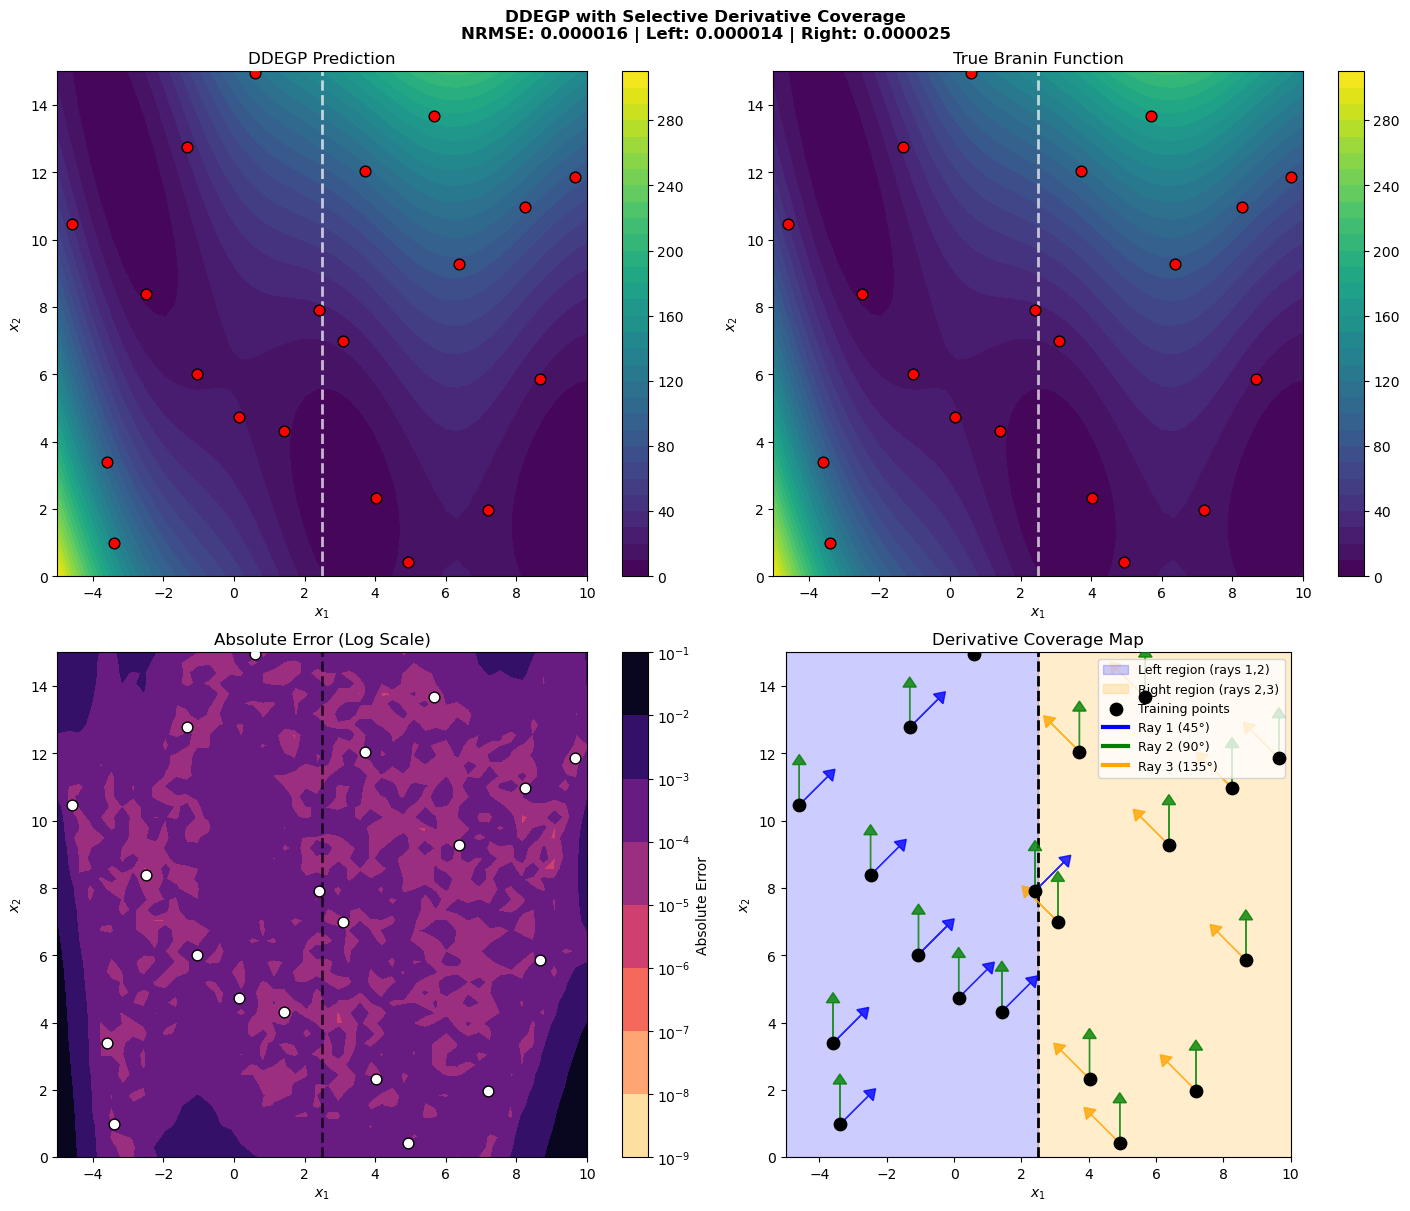

In [23]:
print("=" * 70)
print("Creating visualization...")
print("=" * 70)

# Prepare visualization data
gp_map = y_pred.reshape(X1_grid.shape)
true_map = y_true.reshape(X1_grid.shape)
abs_err = np.abs(gp_map - true_map)
abs_err_clipped = np.clip(abs_err, 1e-8, None)

# Create four-panel figure
fig, axs = plt.subplots(2, 2, figsize=(14, 12), constrained_layout=True)

# Panel 1: GP Prediction
ax = axs[0, 0]
cf1 = ax.contourf(X1_grid, X2_grid, gp_map, cmap='viridis', levels=30)
fig.colorbar(cf1, ax=ax)
ax.axvline(x=x1_midpoint, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter(X_train[:, 0], X_train[:, 1], c='red', s=60, edgecolors='black', zorder=5)
ax.set_title("DDEGP Prediction")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Panel 2: True Function
ax = axs[0, 1]
cf2 = ax.contourf(X1_grid, X2_grid, true_map, cmap='viridis', levels=30)
fig.colorbar(cf2, ax=ax)
ax.axvline(x=x1_midpoint, color='white', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter(X_train[:, 0], X_train[:, 1], c='red', s=60, edgecolors='black', zorder=5)
ax.set_title("True Branin Function")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Panel 3: Absolute Error
ax = axs[1, 0]
cf3 = ax.contourf(X1_grid, X2_grid, abs_err_clipped, norm=LogNorm(), cmap='magma_r', levels=30)
fig.colorbar(cf3, ax=ax, label='Absolute Error')
ax.axvline(x=x1_midpoint, color='black', linestyle='--', linewidth=2, alpha=0.7)
ax.scatter(X_train[:, 0], X_train[:, 1], c='white', s=60, edgecolors='black', zorder=5)
ax.set_title("Absolute Error (Log Scale)")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")

# Panel 4: Derivative Coverage Visualization
ax = axs[1, 1]
ax.set_xlim(domain_bounds[0])
ax.set_ylim(domain_bounds[1])

# Shade regions
ax.axvspan(domain_bounds[0][0], x1_midpoint, alpha=0.2, color='blue', label='Left region (rays 1,2)')
ax.axvspan(x1_midpoint, domain_bounds[0][1], alpha=0.2, color='orange', label='Right region (rays 2,3)')
ax.axvline(x=x1_midpoint, color='black', linestyle='--', linewidth=2)

# Plot training points
ax.scatter(X_train[:, 0], X_train[:, 1], c='black', s=80, edgecolors='black', zorder=10, label='Training points')

# Draw rays at each point based on derivative_locations
ray_length = 1.2
ray_colors = ['blue', 'green', 'orange']  # Colors for rays 1, 2, 3
ray_labels = ['Ray 1 (45°)', 'Ray 2 (90°)', 'Ray 3 (135°)']

for ray_idx in range(rays.shape[1]):
    direction = rays[:, ray_idx]
    point_indices = derivative_locations[ray_idx]

    for i, pt_idx in enumerate(point_indices):
        pt = X_train[pt_idx]
        ax.arrow(pt[0], pt[1], direction[0]*ray_length, direction[1]*ray_length,
                 head_width=0.4, head_length=0.3, fc=ray_colors[ray_idx],
                 ec=ray_colors[ray_idx], alpha=0.8, zorder=5)

# Add legend entries for rays
for ray_idx in range(rays.shape[1]):
    ax.plot([], [], color=ray_colors[ray_idx], linewidth=3, label=ray_labels[ray_idx])

ax.set_title("Derivative Coverage Map")
ax.set_xlabel("$x_1$")
ax.set_ylabel("$x_2$")
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')

plt.suptitle(f"DDEGP with Selective Derivative Coverage\n"
             f"NRMSE: {nrmse:.6f} | Left: {left_nrmse:.6f} | Right: {right_nrmse:.6f}",
             fontsize=12, fontweight='bold')

plt.show()

In [24]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Training configuration:")
print(f"  - {num_training_pts} training points")
print(f"  - 3 directional rays (45°, 90°, 135°)")
print(f"  - Ray 1: {len(derivative_locations[0])} points (left region)")
print(f"  - Ray 2: {len(derivative_locations[1])} points (all)")
print(f"  - Ray 3: {len(derivative_locations[2])} points (right region)")
print(f"  - Total constraints: {num_training_pts} function + "
      f"{sum(len(d) for d in derivative_locations)} derivative = "
      f"{num_training_pts + sum(len(d) for d in derivative_locations)}")
print(f"\nderivative_locations structure:")
print(f"  derivative_locations = [")
print(f"      {derivative_locations[0]},  # Ray 1 (45°)")
print(f"      {derivative_locations[1]},  # Ray 2 (90°)")
print(f"      {derivative_locations[2]}   # Ray 3 (135°)")
print(f"  ]")
print(f"\nModel performance:")
print(f"  - Overall NRMSE: {nrmse:.6f}")
print(f"  - Left region NRMSE: {left_nrmse:.6f}")
print(f"  - Right region NRMSE: {right_nrmse:.6f}")
print("=" * 70)

SUMMARY
Training configuration:
  - 20 training points
  - 3 directional rays (45°, 90°, 135°)
  - Ray 1: 10 points (left region)
  - Ray 2: 20 points (all)
  - Ray 3: 10 points (right region)
  - Total constraints: 20 function + 40 derivative = 60

derivative_locations structure:
  derivative_locations = [
      [1, 2, 4, 6, 7, 8, 13, 14, 15, 18],  # Ray 1 (45°)
      [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19],  # Ray 2 (90°)
      [0, 3, 5, 9, 10, 11, 12, 16, 17, 19]   # Ray 3 (135°)
  ]

Model performance:
  - Overall NRMSE: 0.000016
  - Left region NRMSE: 0.000014
  - Right region NRMSE: 0.000025


In [25]:
import numpy as np
from jetgp.full_ddegp.ddegp import ddegp
import matplotlib.pyplot as plt

print("Modules imported successfully.")

Modules imported successfully.


In [26]:
np.random.seed(42)

# Four rays: 45°, 90°, 135°, 180°
angles = [np.pi/4, np.pi/2, 3*np.pi/4, np.pi]
RAYS = np.array([[np.cos(a) for a in angles],
                 [np.sin(a) for a in angles]])   # shape (2, 4)

print("Ray directions (all four must be in 'rays' at construction):")
for i, a in enumerate(angles):
    print(f"  Ray {i+1}: [{RAYS[0,i]:+.4f}, {RAYS[1,i]:+.4f}]  "
          f"({np.degrees(a):.0f}°)")

# Simple 2D function: f(x1,x2) = x1^2 + x2^2
def f(X):          return X[:, 0]**2 + X[:, 1]**2
def grad_f(X):     return np.stack([2*X[:, 0], 2*X[:, 1]], axis=1)
def dir_deriv(X, ray):
    """Exact directional derivative along a unit ray."""
    g = grad_f(X)                  # (n, 2)
    return (g @ ray).reshape(-1, 1)

Ray directions (all four must be in 'rays' at construction):
  Ray 1: [+0.7071, +0.7071]  (45°)
  Ray 2: [+0.0000, +1.0000]  (90°)
  Ray 3: [-0.7071, +0.7071]  (135°)
  Ray 4: [-1.0000, +0.0000]  (180°)


In [27]:
x_vals = np.linspace(-1, 1, 5)
X_train = np.array([[x1, x2] for x1 in x_vals for x2 in x_vals])
n_train = len(X_train)

y_func = f(X_train).reshape(-1, 1)
# Training derivatives for rays 1, 2, 3 — ray 4 deliberately omitted
y_ray1 = dir_deriv(X_train, RAYS[:, 0])
y_ray2 = dir_deriv(X_train, RAYS[:, 1])
y_ray3 = dir_deriv(X_train, RAYS[:, 2])
y_train = [y_func, y_ray1, y_ray2, y_ray3]

# Only 3 derivative types in training; ray index 4 (column 3) is absent
der_indices = [[[[1, 1]], [[2, 1]], [[3, 1]]]]
derivative_locations = [list(range(n_train))] * 3

print(f"Training points : {n_train}")
print(f"Trained rays    : 1 (45°), 2 (90°), 3 (135°)")
print(f"Untrained ray   : 4 (180°)  — in RAYS array, not in der_indices")

Training points : 25
Trained rays    : 1 (45°), 2 (90°), 3 (135°)
Untrained ray   : 4 (180°)  — in RAYS array, not in der_indices


In [28]:
# Pass the full RAYS array (all 4 columns) even though only 3 are trained.
# This registers e1..e4 in the OTI space, making ray 4 accessible later.
model = ddegp(
    X_train, y_train,
    n_order=1,
    der_indices=der_indices,
    rays=RAYS,                      # <-- all 4 rays
    derivative_locations=derivative_locations,
    normalize=True,
    kernel="SE", kernel_type="anisotropic"
)

print("DDEGP model initialized with n_rays =", model.n_rays)

DDEGP model initialized with n_rays = 4


In [29]:
params = model.optimize_hyperparameters(
    optimizer='powell',
    n_restart_optimizer=5,
    debug=False
)
print("Optimized hyperparameters:", params)

Optimized hyperparameters: [-1.006432   -0.9483721   1.81086979 -5.65213768]


In [30]:
np.random.seed(99)
X_test = np.random.uniform(-1, 1, (60, 2))

# Request ray 4 (180°) — index [[4, 1]] in OTI notation
pred = model.predict(
    X_test, params,
    calc_cov=False,
    return_deriv=True,
    derivs_to_predict=[[[4, 1]]]   # ray 4 — not in training set
)

# pred shape: (2, n_test) — row 0 = f, row 1 = directional deriv along ray 4
f_pred    = pred[0, :]
ray4_pred = pred[1, :]

ray4_true = dir_deriv(X_test, RAYS[:, 3]).flatten()
f_true    = f(X_test).flatten()

rmse_f    = float(np.sqrt(np.mean((f_pred - f_true) ** 2)))
rmse_ray4 = float(np.sqrt(np.mean((ray4_pred - ray4_true) ** 2)))
corr_ray4 = float(np.corrcoef(ray4_pred, ray4_true)[0, 1])

print(f"Function RMSE                : {rmse_f:.4e}")
print(f"Ray-4 RMSE (untrained)       : {rmse_ray4:.4e}")
print(f"Ray-4 correlation            : {corr_ray4:.4f}")

Function RMSE                : 2.5826e-07
Ray-4 RMSE (untrained)       : 7.9975e-07
Ray-4 correlation            : 1.0000


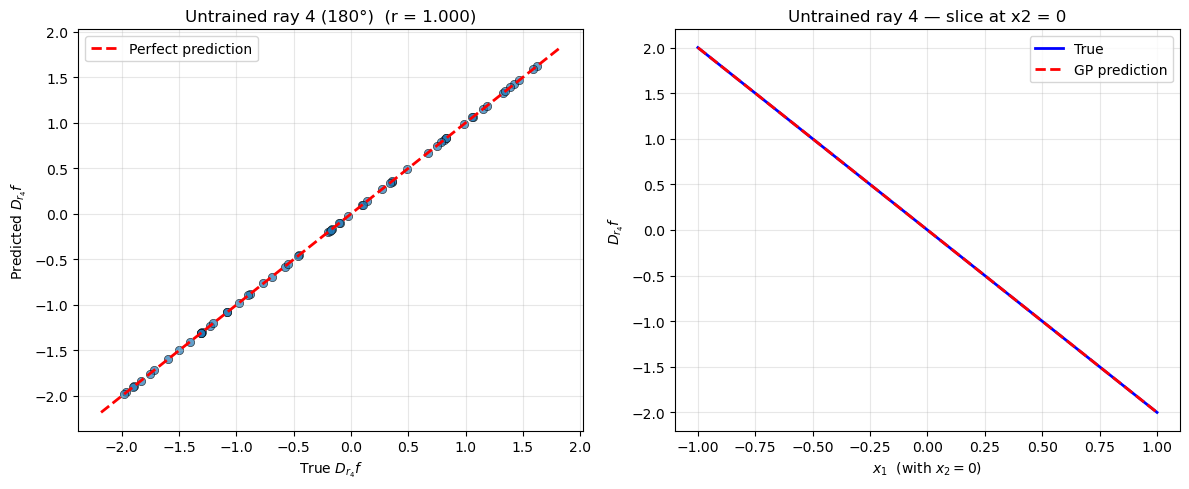

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter: predicted vs true ray-4 directional derivative
axes[0].scatter(ray4_true, ray4_pred, alpha=0.7, edgecolors='k', linewidths=0.5)
lims = [min(ray4_true.min(), ray4_pred.min()) - 0.2,
        max(ray4_true.max(), ray4_pred.max()) + 0.2]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel(r'True $D_{r_4} f$')
axes[0].set_ylabel(r'Predicted $D_{r_4} f$')
axes[0].set_title(f'Untrained ray 4 (180°)  (r = {corr_ray4:.3f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Map over x1 axis (with x2 ≈ 0) for a clean line plot
x1_line = np.linspace(-1, 1, 80)
X_line  = np.column_stack([x1_line, np.zeros(80)])
pred_line = model.predict(X_line, params, calc_cov=False,
                          return_deriv=True, derivs_to_predict=[[[4, 1]]])
true_line = dir_deriv(X_line, RAYS[:, 3]).flatten()

axes[1].plot(x1_line, true_line, 'b-', linewidth=2, label='True')
axes[1].plot(x1_line, pred_line[1, :], 'r--', linewidth=2, label='GP prediction')
axes[1].set_xlabel(r'$x_1$  (with $x_2 = 0$)')
axes[1].set_ylabel(r'$D_{r_4} f$')
axes[1].set_title('Untrained ray 4 — slice at x2 = 0')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()